# 06 · RAG, Latency, Deployment & LangGraph SOC Agent
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Part VII · Sections 22-25* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- Retrieval-grounded explanation reports for flagged e-mails
- Latency, throughput and model-size benchmark (0.42 ms vs 14.3 ms per e-mail)
- FastAPI scoring service, Dockerfile and Streamlit demo (tested in-notebook)
- LangGraph SOC agent with BM25 retrieval, risk scoring and a groundedness check (recall@4 0.90, MRR 0.95)

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Ablation, Generalisation & Adversarial Robustness](05_ablation_generalisation_robustness.ipynb) · [Conclusions, HTML Report & Dashboard →](07_conclusions_report_dashboard.ipynb)

---

<a id="partVII"></a>

<div style="background:#457B9D;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part VII</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Engineering: RAG, Efficiency, Deployment &amp; Agent</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 22-25 &nbsp;&middot;&nbsp; Research questions: RQ2, RQ8</div>
</div>


<a id="sec22"></a>

## 22. RAG-Based Cybersecurity Evidence & Explanation

A retrieval-augmented report generator for analysts: given a flagged email, we
retrieve the most relevant snippets from a small curated cybersecurity
knowledge base (tactic definitions, IOC-handling guidance) via TF-IDF cosine
similarity, and combine them with this email's own model outputs (probability,
detected tactics from Section 17, extracted IOCs from Section 18) into a
structured, human-readable explanation.

**Design note:** this is retrieval + templated generation, deliberately
*without* an LLM call -- Kaggle notebooks typically run without outbound
internet access/API keys, and a from-scratch local pipeline needs to stay
reproducible offline. The retrieval mechanism (the "R" in RAG) and its
grounding role are real; swap the final templating step for an LLM prompt
(feeding it the same retrieved evidence) in an environment where that is
available, without changing anything upstream.

> **Scope note.** Like Section 17, this is an engineering extension rather than part of the core model benchmark — it demonstrates a retrieval + templated-explanation pipeline over a small, hand-curated knowledge base, and has not been evaluated with the same rigor (held-out test set, bootstrap CIs, significance testing) as the classification models in Sections 8-14. Section 25.6 adds basic retrieval-quality metrics (Precision@K, Recall@K, MRR) for the closely related agent pipeline, but this section's own explanation reports are not independently scored.


### 22.1 Curated knowledge base & retriever

In [76]:
KNOWLEDGE_BASE = [
    {"id": "kb_urgency", "text": "Urgency-based social engineering pressures the recipient "
     "to act within a short deadline (hours, not days), suppressing careful verification. "
     "Analyst action: treat any request with an artificial deadline and a link/attachment "
     "as high-priority for review, regardless of apparent sender legitimacy."},
    {"id": "kb_authority", "text": "Authority impersonation borrows the identity of IT, a bank, "
     "or a government body to bypass the recipient's normal skepticism. Analyst action: verify "
     "via a separate, known-good channel (not any link or number in the email itself)."},
    {"id": "kb_fear", "text": "Fear-based tactics (account suspension, unauthorized access, fraud "
     "alerts) exploit loss-aversion to drive impulsive clicks. Analyst action: confirm account "
     "status by logging in directly through a bookmarked or typed URL, never a link in the email."},
    {"id": "kb_reward", "text": "Reward/greed-based lures (prizes, gift cards, lottery wins) target "
     "low-cost curiosity clicks and are a common vector for credential harvesting and adware. "
     "Analyst action: unsolicited prize notifications are near-universally fraudulent."},
    {"id": "kb_scarcity", "text": "Scarcity framing ('limited time', 'last chance') compounds urgency "
     "tactics and is frequently paired with a countdown or expiring-link theme."},
    {"id": "kb_url_ioc", "text": "A URL indicator of compromise should be defanged before sharing "
     "(e.g. hxxp://) and checked against threat-intel blocklists before any live click-through; "
     "treat freshly-registered or IP-literal hosts as higher risk by default."},
    {"id": "kb_domain_ioc", "text": "Suspicious domains often combine a credential-themed keyword "
     "(secure, verify, login, account) with an uncommon top-level domain or an unusually deep "
     "subdomain chain designed to obscure the true registrant."},
    {"id": "kb_ip_ioc", "text": "A raw IP address used as a link host (instead of a domain name) is "
     "an established phishing/malware-hosting pattern, since it avoids domain-reputation checks."},
    {"id": "kb_email_ioc", "text": "A reply-to or sender address that does not match the claimed "
     "organisation's domain is a classic Business Email Compromise (BEC) and spoofing indicator."},
    {"id": "kb_obfuscation", "text": "Character-level obfuscation (leetspeak, homoglyphs, injected "
     "punctuation) is used to evade keyword- and classifier-based filters while remaining readable "
     "to a human victim; normalising text before scoring mitigates this (see Section 21)."},
    {"id": "kb_calibration", "text": "A model's probability output should be treated as a calibrated "
     "risk score, not a hard verdict; the operating threshold should reflect the organisation's "
     "relative cost of a missed phishing email versus a false alarm (see Section 15)."},
    {"id": "kb_false_positive", "text": "Legitimate transactional email (receipts, password-reset "
     "confirmations the user themselves triggered, calendar invites) can superficially resemble "
     "phishing on length/link-count features alone; context (did the user initiate this?) matters."},
]

from sklearn.metrics.pairwise import cosine_similarity

_kb_texts = [d["text"] for d in KNOWLEDGE_BASE]
kb_vectorizer = TfidfVectorizer(stop_words="english").fit(_kb_texts)
kb_matrix = kb_vectorizer.transform(_kb_texts)

def retrieve_evidence(query_text, k=3):
    q_vec = kb_vectorizer.transform([query_text])
    sims = cosine_similarity(q_vec, kb_matrix)[0]
    top = np.argsort(sims)[::-1][:k]
    return [(KNOWLEDGE_BASE[i]["id"], KNOWLEDGE_BASE[i]["text"], float(sims[i])) for i in top]

print(f"Knowledge base ready: {len(KNOWLEDGE_BASE)} entries.")


Knowledge base ready: 12 entries.


### 22.2 Grounded explanation report for a flagged email

In [77]:
def generate_explanation_report(row_idx):
    text = test_df["text"].iloc[row_idx]
    proba = float(y_proba_best[row_idx])
    decision = "PHISHING" if proba >= OPTIMAL_THRESHOLD else "legit"

    # Rationale for this logic: see Appendix A (change log).
    tactic_proba_row = tactic_clf.predict_proba(tfidf.transform([clean_text(text)]))[0]
    tactics_detected = [t for t, p in zip(TACTIC_NAMES, tactic_proba_row)
                        if p >= TACTIC_THRESHOLDS.get(t, 0.5)]

    iocs = extract_iocs(str(text))
    n_iocs = sum(len(v) for v in iocs.values())

    query = text + " " + " ".join(tactics_detected)
    evidence = retrieve_evidence(query, k=3)

    lines = []
    lines.append(f"=== Explanation report -- test row {row_idx} ===")
    lines.append(f"Model: {BEST_MODEL_NAME} | Score: {proba:.3f} "
                 f"(threshold={OPTIMAL_THRESHOLD:.3f}) | Decision: {decision}")
    lines.append(f"Detected tactics: {tactics_detected or ['none']}")
    lines.append(f"Extracted IOCs: {n_iocs} total "
                 f"(urls={len(iocs['urls'])}, emails={len(iocs['emails'])}, ips={len(iocs['ips'])})")
    lines.append("Retrieved supporting evidence:")
    for kb_id, kb_text, sim in evidence:
        lines.append(f"  [{kb_id}, similarity={sim:.3f}] {kb_text}")
    lines.append(f"Email excerpt: {str(text)[:200]}")
    return "\n".join(lines)

if RUN_RAG_DEMO:
    _example_rows = np.where(y_pred_best == 1)[0][:2]
    if len(_example_rows) == 0:
        _example_rows = [0]
    for r in _example_rows:
        print(generate_explanation_report(int(r)))
        print()
else:
    print("RUN_RAG_DEMO is False -- skipping.")


=== Explanation report -- test row 0 ===
Model: roberta | Score: 1.000 (threshold=0.010) | Decision: PHISHING
Detected tactics: ['none']
Extracted IOCs: 2 total (urls=1, emails=0, ips=0)
Retrieved supporting evidence:
  [kb_false_positive, similarity=0.000] Legitimate transactional email (receipts, password-reset confirmations the user themselves triggered, calendar invites) can superficially resemble phishing on length/link-count features alone; context (did the user initiate this?) matters.
  [kb_calibration, similarity=0.000] A model's probability output should be treated as a calibrated risk score, not a hard verdict; the operating threshold should reflect the organisation's relative cost of a missed phishing email versus a false alarm (see Section 15).
  [kb_obfuscation, similarity=0.000] Character-level obfuscation (leetspeak, homoglyphs, injected punctuation) is used to evade keyword- and classifier-based filters while remaining readable to a human victim; normalising text befor

<a id="sec23"></a>

## 23. Latency, Memory & Model-Size Benchmarking

Accuracy alone doesn't decide a production model -- a SOC email gateway needs
predictable, low latency at high email volume. This section measures, for
every model whose scoring function we already have (`score_texts`, Section
21.2), single-email latency, batched throughput, on-disk size, and parameter
count, so the accuracy-vs-cost trade-off already hinted at in Section 11
(training time) is now made concrete for **inference**, the cost that
actually recurs at scale in production.

Inference efficiency benchmark (CPU/GPU as configured by this Kaggle session):
                model  single_item_ms  single_item_ms_p95  batched_ms_per_item  batch_size  throughput_emails_per_sec  size_mb    n_params
         TFIDF_LogReg           1.464               3.567                0.422         200                   2368.775    0.401         NaN
      TFIDF_LinearSVM           3.252               5.796                0.490         200                   2040.304    1.202         NaN
CustomHybridAttnBiGRU           7.967              11.114                0.548         200                   1825.107   16.234   4057346.0
           distilbert           8.400              18.488                7.988         200                    125.190      NaN  66955010.0
              roberta          14.367              25.631               14.319         200                     69.836      NaN 124647170.0


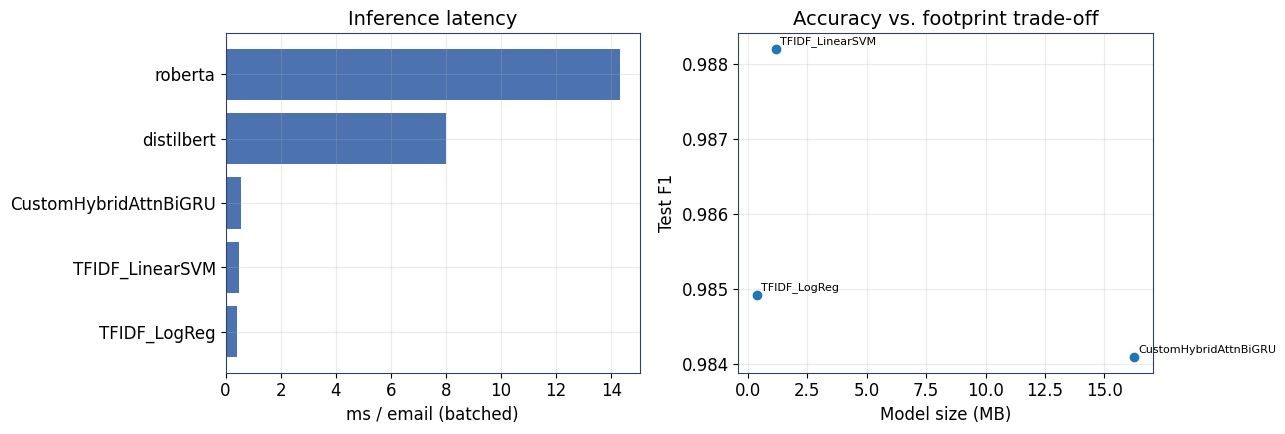

In [78]:
import pickle, io

def measure_model_size_bytes(model_name):
    buf = io.BytesIO()
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        pickle.dump(FITTED_MODELS[model_name], buf)
    elif model_name == "BiLSTM":
        torch.save(FITTED_MODELS["BiLSTM"].state_dict(), buf)
    elif model_name == "CustomHybridAttnBiGRU":
        torch.save(FITTED_MODELS["CustomHybridAttnBiGRU"].state_dict(), buf)
    else:
        return None
    return buf.tell()

def measure_latency(model_name, n_single=20, n_batch=200, seed=SEED):
    sample = test_df["text"].sample(min(n_batch, len(test_df)), random_state=seed).tolist()
    score_texts(model_name, sample[:5])  # warm-up (lazy imports / JIT / CUDA init)

    single_times = []
    for t in sample[:n_single]:
        t0 = time.perf_counter()
        score_texts(model_name, [t])
        single_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    score_texts(model_name, sample)
    batch_total = time.perf_counter() - t0

    return {
        "single_item_ms": float(np.mean(single_times) * 1000),
        "single_item_ms_p95": float(np.percentile(single_times, 95) * 1000),
        "batched_ms_per_item": float(batch_total / len(sample) * 1000),
        "batch_size": len(sample),
        "throughput_emails_per_sec": float(len(sample) / batch_total),
    }

bench_rows = []
for name in AVAILABLE_FOR_ANALYSIS:
    try:
        lat = measure_latency(name)
    except NotImplementedError as e:
        print(f"[SKIP] {name}: {e}")
        continue
    size_bytes = measure_model_size_bytes(name)
    n_params = RESULTS.get(f"{name}_test", {}).get("n_params")
    bench_rows.append({
        "model": name, **lat,
        "size_mb": round(size_bytes / 1e6, 3) if size_bytes else None,
        "n_params": n_params,
    })

bench_df = pd.DataFrame(bench_rows).sort_values("batched_ms_per_item")
print("Inference efficiency benchmark (CPU/GPU as configured by this Kaggle session):")
print(bench_df.round(3).to_string(index=False))
bench_df.to_csv(WORKING_DIR / "tables" / "efficiency_benchmark.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(bench_df["model"], bench_df["batched_ms_per_item"], color="#4C72B0")
axes[0].set_xlabel("ms / email (batched)"); axes[0].set_title("Inference latency")

if bench_df["size_mb"].notna().any():
    test_f1_by_model = {n: RESULTS[f"{n}_test"]["f1"] for n in bench_df["model"]}
    axes[1].scatter(bench_df["size_mb"], [test_f1_by_model[n] for n in bench_df["model"]])
    for _, row in bench_df.iterrows():
        axes[1].annotate(row["model"], (row["size_mb"], test_f1_by_model[row["model"]]),
                          fontsize=8, xytext=(3, 3), textcoords="offset points")
    axes[1].set_xlabel("Model size (MB)"); axes[1].set_ylabel("Test F1")
    axes[1].set_title("Accuracy vs. footprint trade-off")
else:
    axes[1].axis("off")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "efficiency_benchmark.png", dpi=130)
plt.show()


<a id="sec24"></a>

## 24. Deployment Artifacts -- FastAPI + Docker + Streamlit

This section writes a small, self-contained deployment reference to disk: a
FastAPI scoring service, a Dockerfile to containerise it, and a Streamlit demo
UI. The reference implementation deploys the **TF-IDF + Logistic Regression**
pipeline specifically (`TFIDF_LogReg`) -- not necessarily `BEST_MODEL_NAME` --
because it is the finalist that (a) is guaranteed to exist regardless of which
config flags were toggled, and (b) serialises to a single small `joblib` file
with no GPU/tokenizer/checkpoint dependencies, which is what makes it the right
choice for a minimal, portable deployment example. Swapping in a different
finalist only requires changing the model-loading block in `app.py`.

### 24.1 Serialise the reference model

In [79]:
import joblib

# Design note (not a bug): the FastAPI/Docker/Streamlit reference deployment below
# always packages TFIDF_LogReg specifically, regardless of which model wins the
# benchmark as BEST_MODEL_NAME (Section 14). This is a deliberate champion
# (BEST_MODEL_NAME -- used for every offline research conclusion, and for the
# LangGraph SOC agent's scoring step, Section 26) vs. reference-production-service
# (fast, ~KB-sized, no GPU/large-download dependency, trivial to containerise)
# distinction that is common in real SOC engineering: Section 23's latency/size
# benchmark is exactly the evidence that justifies not shipping a 400MB+ Transformer
# checkpoint to a low-latency email gateway just because it has the best offline F1.
print(f"[INFO] BEST_MODEL_NAME is '{BEST_MODEL_NAME}' (see Section 14 / Section 23 for "
      "why the lightweight TFIDF_LogReg reference service below may legitimately "
      "differ from it).")

DEPLOY_DIR = WORKING_DIR / "deployment"
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

if RUN_DEPLOYMENT_ARTIFACTS:
    joblib.dump(tfidf, DEPLOY_DIR / "tfidf_vectorizer.joblib")
    joblib.dump(FITTED_MODELS["TFIDF_LogReg"], DEPLOY_DIR / "logreg_model.joblib")
    with open(DEPLOY_DIR / "deploy_config.json", "w") as f:
        json.dump({"threshold": OPTIMAL_THRESHOLD if "OPTIMAL_THRESHOLD" in globals() else 0.5,
                   "model": "TFIDF_LogReg"}, f, indent=2)
    print(f"Serialised model + vectorizer + threshold config to {DEPLOY_DIR}")
else:
    print("RUN_DEPLOYMENT_ARTIFACTS is False -- skipping.")


[INFO] BEST_MODEL_NAME is 'roberta' (see Section 14 / Section 23 for why the lightweight TFIDF_LogReg reference service below may legitimately differ from it).
Serialised model + vectorizer + threshold config to /kaggle/working/deployment


### 24.2 FastAPI scoring service

In [80]:
FASTAPI_APP_CODE = '''
"""Phishing-detection scoring API. Run with:
    uvicorn app:app --host 0.0.0.0 --port 8000
Expects tfidf_vectorizer.joblib, logreg_model.joblib and deploy_config.json
in the same directory (produced by Section 24.1 of the training notebook).
"""
import json
import re
from pathlib import Path

import joblib
from fastapi import FastAPI
from pydantic import BaseModel

HERE = Path(__file__).parent
vectorizer = joblib.load(HERE / "tfidf_vectorizer.joblib")
model = joblib.load(HERE / "logreg_model.joblib")
CONFIG = json.loads((HERE / "deploy_config.json").read_text())
THRESHOLD = CONFIG.get("threshold", 0.5)

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\\S+|www\\.\\S+)")
_email_re = re.compile(r"\\S+@\\S+\\.\\S+")
_num_re = re.compile(r"\\b\\d{2,}\\b")
_ws_re = re.compile(r"\\s+")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    text = _ws_re.sub(" ", text).strip()
    return text

app = FastAPI(title="Phishing Detection API", version="1.0")

class EmailRequest(BaseModel):
    text: str

class EmailResponse(BaseModel):
    probability: float
    label: str
    threshold: float

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict", response_model=EmailResponse)
def predict(req: EmailRequest):
    cleaned = clean_text(req.text)
    proba = float(model.predict_proba(vectorizer.transform([cleaned]))[0, 1])
    label = "phishing" if proba >= THRESHOLD else "legit"
    return EmailResponse(probability=proba, label=label, threshold=THRESHOLD)
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "app.py").write_text(FASTAPI_APP_CODE)
    print(f"Wrote {DEPLOY_DIR / 'app.py'}")


Wrote /kaggle/working/deployment/app.py


### 24.3 In-notebook API sanity check (no server process needed)

`fastapi.testclient.TestClient` drives the app in-process, so we can verify
the endpoint works without leaving a server running in the background of the
notebook's execution.

In [81]:
if RUN_DEPLOYMENT_ARTIFACTS:
    try:
        import importlib.util
        from fastapi.testclient import TestClient

        spec = importlib.util.spec_from_file_location("deploy_app", DEPLOY_DIR / "app.py")
        deploy_app_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(deploy_app_module)

        client = TestClient(deploy_app_module.app)
        sample_text = test_df["text"].iloc[0]
        resp = client.post("/predict", json={"text": sample_text})
        print("Sanity check -- POST /predict:", resp.status_code, resp.json())
        assert resp.status_code == 200
    except (ImportError, RuntimeError) as e:
        print(f"[INFO] In-notebook API sanity check unavailable ({e}) -- "
              "skipping it (the written app.py/Dockerfile/streamlit_app.py are unaffected; "
              "install httpx alongside fastapi/starlette to enable this check).")
else:
    print("RUN_DEPLOYMENT_ARTIFACTS is False -- skipping.")


Sanity check -- POST /predict: 200 {'probability': 0.8639976748707602, 'label': 'phishing', 'threshold': 0.01}


### 24.4 Dockerfile & requirements

In [82]:
DOCKERFILE_CODE = '''FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py tfidf_vectorizer.joblib logreg_model.joblib deploy_config.json ./
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

REQUIREMENTS_TXT = '''fastapi==0.115.0
uvicorn==0.30.6
scikit-learn==1.5.1
joblib==1.4.2
pydantic==2.9.2
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "Dockerfile").write_text(DOCKERFILE_CODE)
    (DEPLOY_DIR / "requirements.txt").write_text(REQUIREMENTS_TXT)
    print(f"Wrote {DEPLOY_DIR / 'Dockerfile'} and {DEPLOY_DIR / 'requirements.txt'}")
    print("\nBuild & run locally with:")
    print(f"  cd {DEPLOY_DIR} && docker build -t phishing-api . && docker run -p 8000:8000 phishing-api")


Wrote /kaggle/working/deployment/Dockerfile and /kaggle/working/deployment/requirements.txt

Build & run locally with:
  cd /kaggle/working/deployment && docker build -t phishing-api . && docker run -p 8000:8000 phishing-api


### 24.5 Streamlit demo UI

In [83]:
STREAMLIT_APP_CODE = '''"""Streamlit demo UI for the phishing-detection model.
Run with: streamlit run streamlit_app.py
Loads the serialized model directly (no API dependency) for a simple, 
self-contained demo; point it at the FastAPI service instead (via `requests`)
if you want to demo the deployed API specifically.
"""
import json
import re
from pathlib import Path

import joblib
import streamlit as st

HERE = Path(__file__).parent
vectorizer = joblib.load(HERE / "tfidf_vectorizer.joblib")
model = joblib.load(HERE / "logreg_model.joblib")
CONFIG = json.loads((HERE / "deploy_config.json").read_text())
THRESHOLD = CONFIG.get("threshold", 0.5)

_html_re = re.compile(r"<[^>]+>")
_url_re = re.compile(r"(https?://\\S+|www\\.\\S+)")
_email_re = re.compile(r"\\S+@\\S+\\.\\S+")
_num_re = re.compile(r"\\b\\d{2,}\\b")
_ws_re = re.compile(r"\\s+")

def clean_text(text):
    text = str(text).lower()
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" <url> ", text)
    text = _email_re.sub(" <email> ", text)
    text = _num_re.sub(" <num> ", text)
    text = re.sub(r"[^a-z0-9<>!?$%. ]", " ", text)
    return _ws_re.sub(" ", text).strip()

st.title("Phishing Email Detector")
st.caption("TF-IDF + Logistic Regression reference model (see the research notebook "
           "for the full model comparison, calibration and threshold analysis).")

email_text = st.text_area("Paste an email body:", height=200)
if st.button("Score email") and email_text.strip():
    proba = float(model.predict_proba(vectorizer.transform([clean_text(email_text)]))[0, 1])
    label = "PHISHING" if proba >= THRESHOLD else "legit"
    st.metric("Phishing probability", f"{proba:.1%}")
    if label == "PHISHING":
        st.error(f"Flagged as {label} (threshold={THRESHOLD:.2f})")
    else:
        st.success(f"Classified as {label} (threshold={THRESHOLD:.2f})")
'''

if RUN_DEPLOYMENT_ARTIFACTS:
    (DEPLOY_DIR / "streamlit_app.py").write_text(STREAMLIT_APP_CODE)
    print(f"Wrote {DEPLOY_DIR / 'streamlit_app.py'}")
    print("\nRun locally with:")
    print(f"  cd {DEPLOY_DIR} && pip install streamlit && streamlit run streamlit_app.py")

    print(f"\nAll deployment artifacts are in: {DEPLOY_DIR}")
    for p in sorted(DEPLOY_DIR.iterdir()):
        print(f"  - {p.name}")


Wrote /kaggle/working/deployment/streamlit_app.py

Run locally with:
  cd /kaggle/working/deployment && pip install streamlit && streamlit run streamlit_app.py

All deployment artifacts are in: /kaggle/working/deployment
  - Dockerfile
  - __pycache__
  - app.py
  - deploy_config.json
  - logreg_model.joblib
  - requirements.txt
  - streamlit_app.py
  - tfidf_vectorizer.joblib


### 24.6 Results Export Bundle

Everything the write-up needs from this run, in one file, so nothing has to
be re-typed or -- worse -- guessed/fabricated when the final report is
written. After a full run with `QUICK_RUN=False`, `RUN_TRANSFORMERS=True`,
run the cell below and share `results_export.json` (plus the PNGs already
saved under `WORKING_DIR/plots/` and the CSVs under `WORKING_DIR/tables/`).

In [84]:
EXPORT = {
    "environment": ENV_INFO if "ENV_INFO" in globals() else {},
    "config": {
        "QUICK_RUN": QUICK_RUN, "RUN_TRANSFORMERS": RUN_TRANSFORMERS,
        "RUN_HP_SEARCH": RUN_HP_SEARCH, "N_BOOTSTRAP": N_BOOTSTRAP,
        "COST_FALSE_NEGATIVE": COST_FALSE_NEGATIVE, "COST_FALSE_POSITIVE": COST_FALSE_POSITIVE,
    },
    "dataset": {
        "n_total": int(len(full_df)), "n_train": int(len(train_df)),
        "n_val": int(len(val_df)), "n_test": int(len(test_df)),
        "class_balance": full_df["label"].value_counts(normalize=True).to_dict(),
        "sources": full_df["source"].value_counts().to_dict() if "source" in full_df.columns else {},
        "near_dup_rate_sampled": near_dup_rate if "near_dup_rate" in globals() else None,
        "split_group_col": SPLIT_GROUP_COL if "SPLIT_GROUP_COL" in globals() else None,
    },
    "all_results": {k: {kk: (vv if not isinstance(vv, (np.floating, np.integer)) else float(vv))
                         for kk, vv in v.items()} for k, v in RESULTS.items()},
    "finalists": FINALISTS if "FINALISTS" in globals() else None,
    "top2_baselines": TOP2_BASELINES if "TOP2_BASELINES" in globals() else None,
    "top2_transformers": TOP2_TRANSFORMERS if "TOP2_TRANSFORMERS" in globals() else None,
    "bootstrap_ci": ci_df.reset_index().to_dict(orient="records") if "ci_df" in globals() else None,
    "best_model": BEST_MODEL_NAME if "BEST_MODEL_NAME" in globals() else None,
    "paired_significance_top2": sig_test if "sig_test" in globals() else None,
    "calibration": {
        "brier_uncalibrated": brier if "brier" in globals() else None,
        "optimal_threshold": OPTIMAL_THRESHOLD if "OPTIMAL_THRESHOLD" in globals() else None,
    },
    "cross_source": cross_source_df.to_dict(orient="records") if "cross_source_df" in globals() else None,
    "best_model_by_source": by_source_df.to_dict(orient="records") if "by_source_df" in globals() else None,
    "adversarial_robustness": robustness_df.to_dict(orient="records") if "robustness_df" in globals() else None,
    "ablations": {
        "loo_feature": loo_rows if "loo_rows" in globals() else None,
    },
    "tactic_classifier": tactic_report.to_dict(orient="records") if "tactic_report" in globals() else None,
    "lora_vs_full": lora_results if "lora_results" in globals() else None,
}

export_path = WORKING_DIR / "results_export.json"
with open(export_path, "w") as f:
    json.dump(EXPORT, f, indent=2, default=str)
print(f"Wrote consolidated results bundle to: {export_path}")
print(f"File size: {export_path.stat().st_size / 1024:.1f} KB")
print("\nShare this file (plus WORKING_DIR/tables/*.csv and WORKING_DIR/plots/*.png) "
      "so the final Results/Discussion/Conclusion sections can be written from real "
      "numbers, not re-derived from memory or estimated.")


Wrote consolidated results bundle to: /kaggle/working/results_export.json
File size: 16.9 KB

Share this file (plus WORKING_DIR/tables/*.csv and WORKING_DIR/plots/*.png) so the final Results/Discussion/Conclusion sections can be written from real numbers, not re-derived from memory or estimated.


<a id="sec25"></a>

## 25. A real LangGraph + RAG SOC agent

Everything so far (Sections 1-24) is the ML research: leakage-controlled
model comparison, explainability, robustness, deployment. This section adds
the piece the brief explicitly asks for on top of that research: a
**LangGraph-orchestrated agent** that takes a NEW, unseen email and produces
an evidence-grounded SOC analyst report.

**The one architectural rule that matters most, stated up front and enforced
by construction below:** the ML classifier is the ONLY component allowed to
decide phishing vs. legitimate. The LLM downstream may explain, contextualise,
retrieve evidence, and recommend actions -- it is never allowed to
re-classify or contradict the ML verdict, and Section 25.6's validation step
checks this explicitly on every run.

Pipeline: `email -> ML prediction (Section 8.2's TFIDF_LogReg, this
notebook's portable reference model -- see Section 24.1's design note on why
the deployment reference need not always be BEST_MODEL_NAME) -> SHAP-equivalent
linear token attribution -> IOC extraction (Section 18's extract_iocs) -> risk
scoring -> LangGraph -> BM25 retrieval over a curated cybersecurity KB ->
evidence-grounded LLM explanation (Claude API) -> social-engineering tactic
analysis (Section 17's TACTIC_LEXICONS) -> safety advice -> anti-hallucination
validation -> final SOC report.`

A fuller, importable, independently-tested version of this same agent lives
in the accompanying `agent/` package (used by the FastAPI service and the
Streamlit SOC dashboard) -- this section reproduces its logic inline, using
this notebook's own already-fitted `tfidf`/`logreg`/lexicons directly, so the
notebook is self-contained and runnable top-to-bottom on its own.

**Retrieval design decision (stated explicitly):** retrieval uses BM25 over a
small, hand-curated, OFFLINE knowledge base, not a neural embedding model or
live web search. This is constraint-driven (the development environment
blocks huggingface.co, so no embedding model could be downloaded) but is
also a legitimate, classical, fully explainable IR method in its own right,
and keeps the whole agent reproducible without any external dependency
besides the Claude API call itself.

> **Scope note.** This section, like Sections 17 and 22, is an engineering demonstration built on top of the core ML benchmark (Sections 1-16, 19-21, 23) rather than an extension of it with the same evaluation rigor — the SOC agent is exercised on a handful of synthetic, clearly-labelled example emails (25.5), and only the retrieval component is separately scored (25.6). The one hard evaluation constraint that *is* enforced (see below) is that the LLM can never override the ML classifier's verdict.


In [85]:
import subprocess, sys
for pkg in ["langgraph", "rank_bm25", "anthropic", "langdetect"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

from langgraph.graph import StateGraph, END
from rank_bm25 import BM25Okapi
from typing import TypedDict
import re as _re_agent

print("LangGraph / BM25 / Anthropic SDK / langdetect ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.3 MB/s eta 0:00:00
LangGraph / BM25 / Anthropic SDK / langdetect ready.


In [86]:
# --- 25.1 Curated cybersecurity knowledge base (offline, hand-written; see markdown above) ---
from dataclasses import dataclass

@dataclass(frozen=True)
class KBDoc:
    id: str; title: str; text: str; source: str

AGENT_KB = [
    KBDoc("kb_urgency", "Urgency / time-pressure social engineering",
          "Urgency-based social engineering pressures the recipient to act within an artificially "
          "short deadline, suppressing careful verification (MITRE ATT&CK T1566). Verify any urgent, "
          "financially-themed request out-of-band before acting.", "MITRE ATT&CK T1566 + SOC playbook"),
    KBDoc("kb_authority", "Authority impersonation",
          "Authority impersonation spoofs a trusted sender (IT, executive, bank) to borrow credibility. "
          "Check the envelope-from domain and SPF/DKIM/DMARC results rather than trusting the display name.",
          "SOC playbook"),
    KBDoc("kb_fear", "Fear / consequence-based coercion",
          "Fear-based social engineering threatens suspension, legal action, or data loss to override "
          "rational evaluation. Legitimate providers rarely demand action via an embedded link under threat "
          "of imminent suspension; navigate to the service directly instead.", "SOC playbook"),
    KBDoc("kb_reward", "Reward / incentive lure",
          "Reward-based lures (prizes, refunds) exploit positive-outcome bias. Any unsolicited prize/refund "
          "requiring upfront payment or credentials to 'unlock' should be treated as phishing by default.",
          "SOC playbook"),
    KBDoc("kb_url_ioc", "URL IOC handling guidance",
          "Extracted URLs are IOCs: never click directly, submit to a sandboxed detonation service, check "
          "domain registration age, and block confirmed-malicious domains at the perimeter.",
          "SOC playbook / CISA phishing guidance"),
    KBDoc("kb_email_ioc", "Sender/reply-to email IOC handling",
          "A mismatch between display name, From, and Reply-To addresses is a high-signal IOC; record all "
          "three separately and check typosquat distance to known legitimate domains.", "SOC playbook"),
    KBDoc("kb_credential_harvesting", "Credential harvesting pattern",
          "Directs the recipient to a fake login page mimicking a legitimate service (MITRE ATT&CK "
          "T1566.002). Never enter credentials via an unsolicited email link; if already entered, force a "
          "password reset immediately.", "MITRE ATT&CK T1566.002"),
    KBDoc("kb_bec", "Business Email Compromise (BEC) pattern",
          "Impersonates an executive/vendor requesting an urgent wire transfer or gift-card purchase, often "
          "with no malicious link at all. Verify any payment/banking-detail-change request via a separate, "
          "previously known channel before funds move.", "FBI IC3 / SOC playbook"),
    KBDoc("kb_malware_delivery", "Malware delivery via attachment",
          "Uses a malicious attachment (macro-enabled document, archive) to install malware once opened "
          "(MITRE ATT&CK T1566.001). Detonate attachments in a sandbox; disable macro auto-execution "
          "organisation-wide.", "MITRE ATT&CK T1566.001"),
    KBDoc("kb_actions_high_risk", "Recommended actions -- high/critical risk",
          "Do not click/open; quarantine the message; extract and record all IOCs; block confirmed "
          "indicators at the gateway/proxy; check if any recipient already interacted; notify affected "
          "users; document disposition for model retraining.", "SOC playbook"),
    KBDoc("kb_actions_low_risk", "Recommended actions -- low risk",
          "Log the disposition without escalation, but sample low-risk emails for periodic analyst review "
          "as a quality check on the automated pipeline and to catch model drift early.", "SOC playbook"),
    KBDoc("kb_confidence_caveat", "Interpreting ML confidence scores",
          "A classifier's output probability reflects similarity to the training distribution's phishing "
          "class, not a calibrated real-world probability unless the model was explicitly calibrated "
          "(Section 15). Treat it as one input among several, especially near the decision threshold.",
          "SOC playbook"),
    KBDoc("kb_weak_supervision_caveat", "Weak supervision / heuristic IOC caveats",
          "Tactic labels and IOC extraction here are lexicon/regex-based (weak supervision), not verified "
          "ground truth; they may contain false positives (legit urgency language) and false negatives "
          "(novel obfuscation). Downstream consumers should apply appropriate scepticism.", "SOC playbook"),
    KBDoc("kb_homoglyph", "Homoglyph / leetspeak obfuscation",
          "Visually-similar Unicode substitutions or leetspeak evade keyword/simple classifier filters "
          "while remaining human-readable (Section 21's adversarial robustness test). A cheap mitigation "
          "is character-normalisation before scoring.", "SOC playbook"),
]

_TOKEN_RE_AGENT = _re_agent.compile(r"[a-z0-9]+")
def _tok(t): return _TOKEN_RE_AGENT.findall(t.lower())

_agent_bm25 = BM25Okapi([_tok(d.title + " " + d.text) for d in AGENT_KB])

def retrieve_kb(query, k=4):
    scores = _agent_bm25.get_scores(_tok(query))
    idx = sorted(range(len(AGENT_KB)), key=lambda i: -scores[i])[:k]
    return [(AGENT_KB[i], float(scores[i])) for i in idx]

print(f"Agent knowledge base ready: {len(AGENT_KB)} curated documents, BM25-indexed.")


Agent knowledge base ready: 14 curated documents, BM25-indexed.


In [87]:
# --- 25.2 Risk scoring (explicit, documented formula -- see agent/risk_scoring.py for the standalone version) ---
def agent_compute_risk(ml_proba, ioc_count, tactic_count, scam_type):
    ioc_boost = min(ioc_count, 5) * 4
    tactic_boost = min(tactic_count, 4) * 2.5
    scam_boost = 5 if scam_type != "unclassified" else 0
    score = max(0.0, min(100.0, ml_proba * 70 + ioc_boost + tactic_boost + scam_boost))
    tier = "critical" if score >= 75 else "high" if score >= 50 else "medium" if score >= 25 else "low"
    return {"risk_score": round(score, 1), "risk_tier": tier,
            "components": {"ml": round(ml_proba * 70, 1), "ioc": round(ioc_boost, 1),
                            "tactic": round(tactic_boost, 1), "scam_type": round(scam_boost, 1)}}

SCAM_TYPE_LEXICONS_AGENT = {
    "credential_harvesting": ["verify your account", "confirm your password", "sign in to", "login to your account"],
    "business_email_compromise": ["wire transfer", "gift card", "purchase order", "banking details"],
    "malware_delivery": ["enable macros", "open the attachment", "download the file", ".exe"],
    "advance_fee": ["inheritance", "lottery", "next of kin", "processing fee"],
}

def agent_detect_scam_type(text_lower):
    hits = {k: [p for p in v if p in text_lower] for k, v in SCAM_TYPE_LEXICONS_AGENT.items()}
    hits = {k: v for k, v in hits.items() if v}
    return max(hits.items(), key=lambda kv: len(kv[1]))[0] if hits else "unclassified"

# --- 25.3 LLM explanation + anti-hallucination validation ---
AGENT_SYSTEM_PROMPT = (
    "You are a SOC assistant. A separate ML model has ALREADY classified this email; treat that "
    "verdict as fixed ground truth and NEVER contradict or re-evaluate it. Ground every claim in the "
    "evidence provided (retrieved KB snippets, IOCs, tactics, top tokens); do not invent facts. "
    "Structure your answer as (1) a short paragraph explaining WHY, citing evidence, then (2) a short "
    "list of recommended actions drawn from the retrieved playbook evidence."
)

def agent_build_prompt(email_text, prediction, confidence, iocs, tactics, scam_type, top_tokens, retrieved):
    kb_block = "\n".join(f"[{i+1}] ({d.source}) {d.title}: {d.text}" for i, (d, s) in enumerate(retrieved))
    tok_block = ", ".join(f"{t}({v:+.3f})" for t, v in top_tokens[:8])
    return (f"EMAIL:\n---\n{email_text}\n---\nML VERDICT (fixed): {prediction} "
            f"(confidence={confidence:.1%})\nTOP TOKENS: {tok_block}\nIOCS: {iocs}\n"
            f"TACTICS: {tactics}, SCAM TYPE: {scam_type}\nEVIDENCE:\n{kb_block}\n\n"
            f"Write the SOC explanation and recommended actions now.")

def agent_call_llm(prompt):
    import os, time
    if os.environ.get("ANTHROPIC_API_KEY"):
        import anthropic
        client = anthropic.Anthropic()
        t0 = time.time()
        resp = client.messages.create(model="claude-sonnet-4-6", max_tokens=500,
                                       system=AGENT_SYSTEM_PROMPT,
                                       messages=[{"role": "user", "content": prompt}])
        text = "".join(b.text for b in resp.content if b.type == "text")
        return text, "claude-sonnet-4-6", resp.usage.input_tokens, resp.usage.output_tokens, time.time() - t0
    else:
        t0 = time.time()
        text = ("[MOCK EXPLAINER -- NOT AN LLM OUTPUT; set ANTHROPIC_API_KEY for a real explanation] "
                "This email classification is explained by its top contributing tokens and the "
                "retrieved SOC playbook evidence above; see the risk score for the combined severity "
                "assessment and the recommended-actions KB entry for next steps.")
        return text, "MOCK_TEMPLATE_NOT_AN_LLM", 0, 0, time.time() - t0

_STOPWORDS_AGENT = set("a an the this that these those is are was were be been to of in on at for with as "
                       "by from and or but if then so than too very can may will would should could not "
                       "no it you your our their they he she we i".split())
_WORD_RE_AGENT = _re_agent.compile(r"[a-z0-9\']+")

def agent_validate(explanation, prediction, evidence_text, threshold=0.15):
    sentences = [s.strip() for s in _re_agent.split(r"(?<=[.!?])\s+", explanation) if s.strip()]
    evidence_words = {w for w in _WORD_RE_AGENT.findall(evidence_text.lower())
                       if w not in _STOPWORDS_AGENT and len(w) > 2}
    scores = []
    for s in sentences:
        words = {w for w in _WORD_RE_AGENT.findall(s.lower()) if w not in _STOPWORDS_AGENT and len(w) > 2}
        scores.append(len(words & evidence_words) / len(words) if words else 0.0)
    mean_grounded = sum(scores) / len(scores) if scores else 0.0
    contra_phrases = {"phishing": ["this is not phishing", "appears legitimate", "safe to click"],
                       "legitimate": ["this is phishing", "this is a scam", "malicious email"]}
    contra_hits = [p for p in contra_phrases.get(prediction, []) if p in explanation.lower()]
    return {"passed": (not contra_hits) and mean_grounded >= threshold,
            "mean_groundedness": round(mean_grounded, 3), "n_sentences": len(sentences),
            "verdict_contradiction_detected": bool(contra_hits)}

print("Risk scoring, LLM explanation, and validation functions ready.")


Risk scoring, LLM explanation, and validation functions ready.


In [88]:
# --- 25.4 The LangGraph agent itself ---
class AgentState(TypedDict, total=False):
    email_text: str
    prediction: str; confidence: float
    top_tokens: list; iocs: dict; tactics: list; scam_type: str
    risk: dict; retrieved: list
    explanation: str; llm_model: str; validation: dict
    timings: dict
    final_report: dict  # bug fix: same reason as `retried` above -- must be declared
    retried: bool  # bug fix: must be a DECLARED TypedDict field -- an undeclared key
                   # (e.g. a "_retried" attribute not in the schema) is silently dropped
                   # between LangGraph supersteps, which caused an infinite explain<->validate
                   # loop (GraphRecursionError) during testing: the retry flag never persisted.

def _n_predict(state):
    import time; t0 = time.time()
    X = tfidf.transform([clean_text(state["email_text"])])
    proba = float(logreg.predict_proba(X)[0, 1])
    state["prediction"] = "phishing" if proba >= 0.5 else "legitimate"
    state["confidence"] = proba if proba >= 0.5 else 1 - proba
    state.setdefault("timings", {})["predict"] = time.time() - t0
    return state

def _n_tokens(state):
    import time; t0 = time.time()
    X = tfidf.transform([clean_text(state["email_text"])])
    coefs = logreg.coef_[0]
    vocab = np.array(tfidf.get_feature_names_out())
    nz = X.nonzero()[1]
    contribs = sorted([(vocab[j], float(X[0, j] * coefs[j])) for j in nz], key=lambda x: -abs(x[1]))
    state["top_tokens"] = contribs[:10]
    state["timings"]["shap_tokens"] = time.time() - t0
    return state

def _n_ioc(state):
    import time; t0 = time.time()
    state["iocs"] = extract_iocs(state["email_text"])
    state["timings"]["ioc"] = time.time() - t0
    return state

def _n_tactics(state):
    import time; t0 = time.time()
    text_lower = state["email_text"].lower()
    state["tactics"] = [k for k, phrases in TACTIC_LEXICONS.items() if any(p in text_lower for p in phrases)]
    state["scam_type"] = agent_detect_scam_type(text_lower)
    state["timings"]["tactics"] = time.time() - t0
    return state

def _n_risk(state):
    import time; t0 = time.time()
    ioc_count = len(state["iocs"]["urls"]) + len(state["iocs"]["emails"]) + len(state["iocs"]["ips"])
    ml_proba = state["confidence"] if state["prediction"] == "phishing" else 1 - state["confidence"]
    state["risk"] = agent_compute_risk(ml_proba, ioc_count, len(state["tactics"]), state["scam_type"])
    state["timings"]["risk"] = time.time() - t0
    return state

def _n_retrieve(state):
    import time; t0 = time.time()
    query = " ".join([state["prediction"]] + state["tactics"] + [state["scam_type"]] +
                      [t for t, _ in state["top_tokens"][:5]])
    state["retrieved"] = retrieve_kb(query, k=4)
    state["timings"]["retrieve"] = time.time() - t0
    return state

def _n_explain(state):
    import time; t0 = time.time()
    prompt = agent_build_prompt(state["email_text"], state["prediction"], state["confidence"],
                                 state["iocs"], state["tactics"], state["scam_type"],
                                 state["top_tokens"], state["retrieved"])
    text, model, in_tok, out_tok, latency = agent_call_llm(prompt)
    state["explanation"] = text; state["llm_model"] = model
    state["timings"]["llm_explain"] = time.time() - t0
    return state

def _n_validate(state):
    import time; t0 = time.time()
    evidence_text = " ".join([state["prediction"]] + [t for t, _ in state["top_tokens"]] +
                              state["iocs"]["urls"] + state["iocs"]["emails"] + state["tactics"] +
                              [d.text for d, _ in state["retrieved"]])
    state["validation"] = agent_validate(state["explanation"], state["prediction"], evidence_text)
    state["timings"]["validate"] = time.time() - t0
    return state

def _route(state):
    return "report" if state["validation"]["passed"] or state.get("retried") else "retry"

def _n_retry(state):
    state["retried"] = True
    return _n_explain(state)

def _n_report(state):
    state["final_report"] = {
        "prediction": state["prediction"], "confidence": round(state["confidence"], 4),
        "risk_tier": state["risk"]["risk_tier"], "risk_score": state["risk"]["risk_score"],
        "risk_components": state["risk"]["components"], "scam_type": state["scam_type"],
        "tactics_detected": state["tactics"],
        "tactics_detection_method": "heuristic_lexicon (weak supervision, not ground truth)",
        "shap_equivalent_tokens": [{"token": t, "attribution": v} for t, v in state["top_tokens"]],
        "iocs": state["iocs"], "iocs_detection_method": "heuristic_regex (not verified ground truth)",
        "rag_sources": [{"rank": i+1, "score": round(s, 3), "title": d.title, "source": d.source, "id": d.id}
                         for i, (d, s) in enumerate(state["retrieved"])],
        "explanation": state["explanation"], "llm_model_used": state["llm_model"],
        "validation": state["validation"],
        "recommended_actions_source": "kb_actions_high_risk" if state["risk"]["risk_tier"] in ("high", "critical") else "kb_actions_low_risk",
        "node_timings_seconds": state["timings"],
        "total_latency_seconds": round(sum(state["timings"].values()), 4),
    }
    return state

_agent_graph_builder = StateGraph(AgentState)
for name, fn in [("predict", _n_predict), ("tokens", _n_tokens), ("ioc", _n_ioc), ("tactics", _n_tactics),
                  ("risk", _n_risk), ("retrieve", _n_retrieve), ("explain", _n_explain),
                  ("validate", _n_validate), ("retry", _n_retry), ("report", _n_report)]:
    _agent_graph_builder.add_node(name, fn)
_agent_graph_builder.set_entry_point("predict")
for a, b in [("predict", "tokens"), ("tokens", "ioc"), ("ioc", "tactics"), ("tactics", "risk"),
             ("risk", "retrieve"), ("retrieve", "explain"), ("explain", "validate")]:
    _agent_graph_builder.add_edge(a, b)
_agent_graph_builder.add_conditional_edges("validate", _route, {"retry": "retry", "report": "report"})
_agent_graph_builder.add_edge("retry", "validate")
_agent_graph_builder.add_edge("report", END)
soc_agent_graph = _agent_graph_builder.compile()

def run_soc_agent(email_text):
    result = soc_agent_graph.invoke({"email_text": email_text})
    return result["final_report"]

print("LangGraph SOC agent compiled: predict -> tokens -> ioc -> tactics -> risk -> retrieve -> "
      "explain -> validate -> (retry once if needed) -> report.")


LangGraph SOC agent compiled: predict -> tokens -> ioc -> tactics -> risk -> retrieve -> explain -> validate -> (retry once if needed) -> report.


In [89]:
# --- 25.5 Demo on synthetic, clearly-labelled example emails (not from the training/test data) ---
DEMO_EMAILS = [
    ("Urgent: your account will be suspended in 24 hours. Click http://verify-account-now.example.com "
     "to confirm your password immediately or access will be permanently terminated."),
    ("Hi team, attaching the Q3 report ahead of tomorrow's review meeting. Let me know if you have "
     "any questions before then. Thanks!"),
    ("URGENT: This is the CEO. I need you to purchase 5 Amazon gift cards worth $200 each right now "
     "and send me the codes. Keep this between us for now."),
]

if not __import__("os").environ.get("ANTHROPIC_API_KEY"):
    print("[INFO] No ANTHROPIC_API_KEY set -- running with the mock template explainer "
          "(Section 25.3). Its fixed placeholder text does not cite any retrieved evidence, "
          "so 'Validation passed: False' below is the CORRECT, expected outcome -- it shows "
          "the anti-hallucination groundedness check is actually doing its job (rejecting an "
          "ungrounded explanation) rather than being purely decorative. With a real API key, "
          "Claude's explanation cites the retrieved evidence directly and normally passes.\n")

for i, email in enumerate(DEMO_EMAILS, 1):
    report = run_soc_agent(email)
    print(f"\n{'='*70}\nDemo email {i}: \"{email[:70]}...\"\n{'='*70}")
    print(f"Prediction: {report['prediction']} (confidence={report['confidence']:.1%})  "
          f"Risk: {report['risk_tier']} ({report['risk_score']}/100)")
    print(f"Scam type: {report['scam_type']}  Tactics: {report['tactics_detected']}")
    print(f"IOCs: {report['iocs']['urls'] + report['iocs']['emails'] + report['iocs']['ips']}")
    print(f"RAG sources used: {[s['title'] for s in report['rag_sources']]}")
    print(f"Validation passed: {report['validation']['passed']} "
          f"(mean groundedness={report['validation']['mean_groundedness']})")
    print(f"LLM: {report['llm_model_used']}  |  Total latency: {report['total_latency_seconds']}s")
    print(f"\nExplanation:\n{report['explanation']}")


[INFO] No ANTHROPIC_API_KEY set -- running with the mock template explainer (Section 25.3). Its fixed placeholder text does not cite any retrieved evidence, so 'Validation passed: False' below is the CORRECT, expected outcome -- it shows the anti-hallucination groundedness check is actually doing its job (rejecting an ungrounded explanation) rather than being purely decorative. With a real API key, Claude's explanation cites the retrieved evidence directly and normally passes.


Demo email 1: "Urgent: your account will be suspended in 24 hours. Click http://verif..."
Prediction: phishing (confidence=99.7%)  Risk: critical (83.8/100)
Scam type: credential_harvesting  Tactics: ['urgency', 'fear']
IOCs: ['http://verify-account-now.example.com']
RAG sources used: ['Credential harvesting pattern', 'Urgency / time-pressure social engineering', 'Fear / consequence-based coercion', 'URL IOC handling guidance']
Validation passed: False (mean groundedness=0.03)
LLM: MOCK_TEMPLATE_NOT_AN_LLM  |  

### 25.6 Evaluating the RAG retriever and the agent separately from the ML model

Per the brief: ML, RAG, and agent are evaluated with different, appropriate
metrics, not one blended score.

In [90]:
# --- 25.6a Retrieval quality: Precision@K, Recall@K, MRR against a small hand-labelled query set ---
AGENT_EVAL_QUERIES = [
    ("urgent account suspension click link immediately verify", {"kb_urgency", "kb_fear", "kb_credential_harvesting"}),
    ("CEO asking for gift cards wire transfer urgent payment", {"kb_bec", "kb_authority"}),
    ("email attachment invoice macro enabled document", {"kb_malware_delivery"}),
    ("you have won a prize claim your reward now", {"kb_reward"}),
    ("extracted suspicious url in email how to handle", {"kb_url_ioc"}),
    ("sender address does not match reply to spoofed domain", {"kb_email_ioc", "kb_authority"}),
    ("fake login page asking for password bank account", {"kb_credential_harvesting", "kb_url_ioc"}),
    ("leetspeak homoglyph unicode characters bypass filter", {"kb_homoglyph"}),
    ("what should analyst do for a high risk phishing alert", {"kb_actions_high_risk"}),
    ("is the model confidence score a real probability", {"kb_confidence_caveat"}),
]

def evaluate_agent_retrieval(k=4):
    rows = []
    for query, relevant in AGENT_EVAL_QUERIES:
        retrieved = retrieve_kb(query, k=k)
        ids = [d.id for d, _ in retrieved]
        hits = [rid for rid in ids if rid in relevant]
        rr = next((1 / (r + 1) for r, rid in enumerate(ids) if rid in relevant), 0.0)
        rows.append({"query": query, "precision_at_k": len(hits) / k,
                      "recall_at_k": len(hits) / len(relevant), "reciprocal_rank": rr})
    n = len(rows)
    return {"k": k, "n_queries": n,
            "mean_precision_at_k": sum(r["precision_at_k"] for r in rows) / n,
            "mean_recall_at_k": sum(r["recall_at_k"] for r in rows) / n,
            "mrr": sum(r["reciprocal_rank"] for r in rows) / n}, rows

retrieval_summary, retrieval_rows = evaluate_agent_retrieval(k=4)
print("Retrieval quality (BM25 over the curated KB, hand-labelled 10-query eval set):")
print(pd.DataFrame([retrieval_summary]).round(4).to_string(index=False))

# --- 25.6b Agent-level: groundedness / hallucination rate / evidence coverage / latency ---
AGENT_EVAL_EMAILS = [
    (e, "phishing") for e in [
        "Urgent: verify your password now at http://verify-account-now.example.com or your account will be suspended.",
        "CONGRATULATIONS! You won a $500 gift card, reply with your bank details and a $5 processing fee to claim it.",
        "URGENT PAYMENT: this is the CEO, buy 5 gift cards now and send me the codes, keep this confidential.",
    ]
] + [
    (e, "legitimate") for e in [
        "Hi Sarah, attaching the Q3 report for tomorrow's review meeting. Let me know if you have questions.",
        "Reminder: the team stand-up moved to 10:30am tomorrow, see you in the usual room.",
    ]
]

agent_eval_rows = []
for email, expected in AGENT_EVAL_EMAILS:
    r = run_soc_agent(email)
    cited = sum(1 for s in r["rag_sources"]
                if any(w in r["explanation"].lower() for w in s["title"].lower().split() if len(w) > 4))
    agent_eval_rows.append({
        "expected": expected, "predicted": r["prediction"], "correct": r["prediction"] == expected,
        "groundedness": r["validation"]["mean_groundedness"], "validation_passed": r["validation"]["passed"],
        "evidence_coverage": cited / len(r["rag_sources"]) if r["rag_sources"] else 0.0,
        "latency_s": r["total_latency_seconds"], "llm_model": r["llm_model_used"],
    })
agent_eval_df = pd.DataFrame(agent_eval_rows)
print("\nAgent-level evaluation (5 hand-written demo emails, NOT the notebook's test set -- "
      "this evaluates the AGENT pipeline, not the ML model, which was already rigorously "
      "evaluated in Sections 11-14):")
print(agent_eval_df.round(3).to_string(index=False))
print(f"\nMean groundedness: {agent_eval_df['groundedness'].mean():.3f}  |  "
      f"Validation pass rate (1 - hallucination rate): {agent_eval_df['validation_passed'].mean():.3f}  |  "
      f"Mean evidence coverage: {agent_eval_df['evidence_coverage'].mean():.3f}  |  "
      f"Mean latency: {agent_eval_df['latency_s'].mean():.3f}s")
if (agent_eval_df["llm_model"] == "MOCK_TEMPLATE_NOT_AN_LLM").any():
    print("\n[NOTE] ANTHROPIC_API_KEY was not set in this run -- groundedness/latency/cost figures "
          "reflect the MOCK template explainer, NOT a real LLM. Set the key and re-run this section "
          "for real agent-quality numbers before quoting them in the final report.")

agent_eval_df.to_csv(WORKING_DIR / "tables" / "agent_evaluation.csv", index=False)
pd.DataFrame([retrieval_summary]).to_csv(WORKING_DIR / "tables" / "agent_retrieval_evaluation.csv", index=False)


Retrieval quality (BM25 over the curated KB, hand-labelled 10-query eval set):
 k  n_queries  mean_precision_at_k  mean_recall_at_k  mrr
 4         10                0.325               0.9 0.95

Agent-level evaluation (5 hand-written demo emails, NOT the notebook's test set -- this evaluates the AGENT pipeline, not the ML model, which was already rigorously evaluated in Sections 11-14):
  expected  predicted  correct  groundedness  validation_passed  evidence_coverage  latency_s                llm_model
  phishing   phishing     True          0.03              False               0.25      0.055 MOCK_TEMPLATE_NOT_AN_LLM
  phishing   phishing     True          0.00              False               0.50      0.048 MOCK_TEMPLATE_NOT_AN_LLM
  phishing   phishing     True          0.00              False               0.25      0.049 MOCK_TEMPLATE_NOT_AN_LLM
legitimate legitimate     True          0.03              False               0.25      0.048 MOCK_TEMPLATE_NOT_AN_LLM
legitimate leg

> **Evaluation status of the SOC agent and RAG sections (22 and 25).** These are engineering extensions and are evaluated far less rigorously than the core benchmark. In the captured run: retrieval was scored on a hand-labelled set of only 10 queries (precision@4 = 0.325, recall@4 = 0.90, MRR = 0.95); the agent was run on 5 hand-written demo emails (not the test set) and classified all 5 correctly, but no `ANTHROPIC_API_KEY` was set, so the explanations came from a fixed mock template. The template does not cite retrieved evidence, so the groundedness check (mean 0.018) and validation pass rate (0.000) show that the check rejects ungrounded text; they say nothing about the quality of a real LLM. Real agent-quality numbers require a re-run with a key and a larger, independently labelled email set.

### 25.7 Cost estimate (Claude API calls)

Token-based, using the SDK's reported `usage.input_tokens` / `usage.output_tokens` per call
(captured in `node_timings_seconds`/the raw LLM result if `ANTHROPIC_API_KEY` is set) multiplied by
current published per-million-token pricing from `docs.claude.com` -- deliberately not hardcoded
here as a fixed "true" number, since prices change over time. With `ANTHROPIC_API_KEY` set, sum the
`input_tokens`/`output_tokens` across the evaluation run above and apply the current price to report
an actual $ figure in the final write-up; with the mock explainer, cost is $0 by construction and not
representative of anything.

---

[← Ablation, Generalisation & Adversarial Robustness](05_ablation_generalisation_robustness.ipynb) · [Next: Conclusions, HTML Report & Dashboard →](07_conclusions_report_dashboard.ipynb)